# Лабораторная работа 2

## Полносвязная нейронная сеть

Реализовать нейронную сеть, состоящую из двух полносвязных слоев и решающую задачу классификации на наборе данных из лабораторной работы 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scripts.classifiers.neural_net import TwoLayerNet

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

1. Добавьте реализации методов класса TwoLayerNet . Проверьте вашу реализацию на модельных данных (Код приведен ниже).  

In [2]:
input_size = 4
hidden_size = 10
num_classes = 3
num_inputs = 5

def init_toy_model():
    np.random.seed(0)
    return TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1)

def init_toy_data():
    np.random.seed(1)
    X = 10 * np.random.randn(num_inputs, input_size)
    y = np.array([0, 1, 2, 2, 1])
    return X, y

net = init_toy_model()
X, y = init_toy_data()

In [3]:

loss, grads = net.loss(X, y, reg=0.05)
print('Loss:', loss)

Loss: 1.3037878913298202


# Прямой проход: вычисление выхода сети

Реализуйте первую часть  метода TwoLayerNet.loss, вычисляющую оценки классов для входных данных. 

Сравните ваш выход сети с эталонными значениями. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-7) .

In [4]:
scores = net.loss(X)
print('Your scores:')
print(scores)
print()
print('correct scores:')
correct_scores = np.asarray([
  [-0.81233741, -1.27654624, -0.70335995],
  [-0.17129677, -1.18803311, -0.47310444],
  [-0.51590475, -1.01354314, -0.8504215 ],
  [-0.15419291, -0.48629638, -0.52901952],
  [-0.00618733, -0.12435261, -0.15226949]])
print(correct_scores)
print()


print('Difference between your scores and correct scores:')
print(np.sum(np.abs(scores - correct_scores)))

Your scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

correct scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Difference between your scores and correct scores:
3.6802720745909845e-08



# Прямой проход: вычисление loss

Реализуйте вторую часть метода, вычисляющую значение функции потерь. Сравните с эталоном. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-12) .

In [5]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.30378789133

print('Difference between your loss and correct loss:')
print(np.sum(np.abs(loss - correct_loss)))

Difference between your loss and correct loss:
1.7985612998927536e-13


# Обратный проход

Реализуйте третью часть метода loss. Используйте численную реализацию расчета градиента для проверки вашей реализации обратного прохода.  Если прямой и обратный проходы реализованы верно, то ошибка будет < 1e-8 для каждой из переменных W1, W2, b1, и b2. 


In [6]:
from scripts.gradient_check import eval_numerical_gradient

loss, grads = net.loss(X, y, reg=0.05)

for param_name in grads:
    f = lambda W: net.loss(X, y, reg=0.05)[0]
    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)
    print('%s max relative error: %e' % (param_name, rel_error(param_grad_num, grads[param_name])))

W2 max relative error: 3.440708e-09
b2 max relative error: 4.447625e-11
W1 max relative error: 3.561318e-09
b1 max relative error: 2.738421e-09


# Обучение нейронной сети на смоделированных данных

Реализуйте методы TwoLayerNet.train и TwoLayerNet.predict. Обучайте сеть до тех пор, пока значение loss не будет < 0.02.


Final training loss:  0.017149607938732093


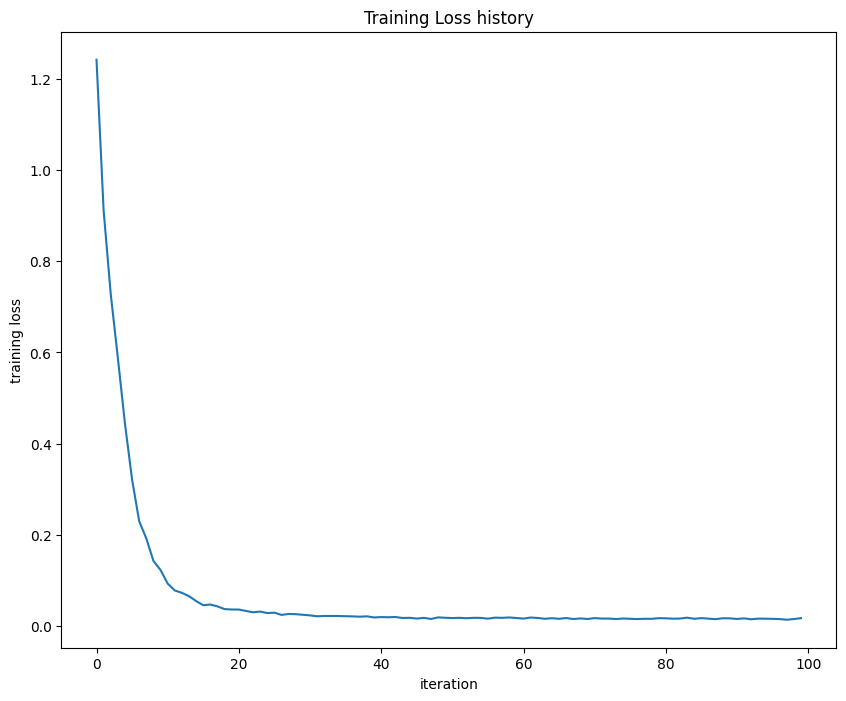

In [7]:
net = init_toy_model()
stats = net.train(X, y, X, y,
            learning_rate=1e-1, reg=5e-6,
            num_iters=100, verbose=False)

print('Final training loss: ', stats['loss_history'][-1])


plt.plot(stats['loss_history'])
plt.xlabel('iteration')
plt.ylabel('training loss')
plt.title('Training Loss history')
plt.show()

# Обучение нейронной сети на реальном наборе данных (CIFAR-10, MNIST)

Загрузите набор данных, соответствующий вашему варианту. 

Разделите данные на обучающую, тестовую и валидационную выборки.

Выполните предобработку данных, как в ЛР 1. 

Обучите нейронную сеть на ваших данных. 

При сдаче лабораторной работы объясните значения всех параметров метода train.

In [ ]:

import os
import urllib.request
import tarfile
from scripts.data_utils import load_CIFAR10

dataset_dir = 'scripts/datasets'
tar_filename = "cifar-10-python.tar.gz"
url = "https://www.cs.toronto.edu/~kriz/" + tar_filename
tar_path = os.path.join(dataset_dir, tar_filename)
final_folder = os.path.join(dataset_dir, 'cifar-10-batches-py')

if not os.path.exists(dataset_dir):
    os.makedirs(dataset_dir)
    print(f"Directory {dataset_dir} created.")

if not os.path.exists(final_folder):
    print("Downloading CIFAR-10... Please wait (approx. 170MB).")
    urllib.request.urlretrieve(url, tar_path)
    
    print("Extracting files...")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(path=dataset_dir)
    
    os.remove(tar_path)
    print(f"Successfully downloaded and extracted to {final_folder}")
else:
    print("Dataset already exists, skipping download.")

    cifar10_dir = 'scripts/datasets/cifar-10-batches-py'

try:
   del X_train, y_train
   del X_val, y_val
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_val, y_val = load_CIFAR10(cifar10_dir)

print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_val.shape)
print('Test labels shape: ', y_val.shape)
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
mean_image = np.mean(X_train, axis=0)
X_train -= mean_image
X_val -= mean_image

print('New Training data shape: ', X_train.shape)

Dataset already exists, skipping download.
Clear previously loaded data.
Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)
New Training data shape:  (50000, 3072)


In [14]:
input_size = 32 * 32 * 3
hidden_size = 50
num_classes = 10
net = TwoLayerNet(input_size, hidden_size, num_classes)

stats = net.train(X_train, y_train, X_val, y_val,
            num_iters=1000, batch_size=200,
            learning_rate=1e-4, learning_rate_decay=0.95,
            reg=0.25, verbose=True)

val_acc = (net.predict(X_val) == y_val).mean()
print('Validation accuracy: ', val_acc)

iteration 0 / 1000: loss 2.302982
iteration 100 / 1000: loss 2.302592
iteration 200 / 1000: loss 2.299342
iteration 300 / 1000: loss 2.270356
iteration 400 / 1000: loss 2.174749
iteration 500 / 1000: loss 2.136342
iteration 600 / 1000: loss 2.043434
iteration 700 / 1000: loss 2.082431
iteration 800 / 1000: loss 2.070517
iteration 900 / 1000: loss 1.950688
Validation accuracy:  0.2764


Параметры метода train: 
* X_train, y_train, X_val, y_val: Обучающие данные и валидационные данные 
* num_iters=1000: Количество обновления весов
* batch_size=200: Размер 1 пакета (батча) обработки
* learning_rate=1e-4: Скорость обучения (шаг). 
* learning_rate_decay=0.95: коэффициент инерции для шага, применяется в adam и других оптимизаторах
* reg=0.25: Сила регуляризации. 
* verbose=True: Если True, сеть будет печатать значение лосса каждые 100 итераций.

Используя параметры по умолчанию, вы можете получить accuracy, примерно равный 0.29. 

Проведите настройку гиперпараметров для увеличения accuracy. Поэкспериментируйте со значениями гиперпараметров, например, с количеством скрытых слоев, количеством эпох, скорости обучения и др. Ваша цель - максимально увеличить accuracy полносвязной сети на валидационном наборе. Различные эксперименты приветствуются. Например, вы можете использовать методы для сокращения размерности признакового пространства (например, PCA), добавить dropout слои и др. 

Для лучшей модели вычислите acсuracy на тестовом наборе. 

Для отладки процесса обучения часто помогают графики изменения loss и accuracy в процессе обучения. Ниже приведен код построения таких графиков. 

In [ ]:
best_net = None
best_val = -1 
results = {}
hidden_sizes = [50, 80, 100]
learning_rates = [5e-4, 1e-3, 1.5e-3]
regularization_strengths = [0.1, 0.25, 0.5]
print("Starting hyperparameter tuning...")
for hs in hidden_sizes:
    for lr in learning_rates:
        for rg in regularization_strengths:
            net = TwoLayerNet(input_size, hs, num_classes)
            stats = net.train(X_train, y_train, X_val, y_val,
                          num_iters=1500, batch_size=200,
                          learning_rate=lr, learning_rate_decay=0.95,
                          reg=rg, verbose=False)
            val_acc = (net.predict(X_val) == y_val).mean()
            print(f'hs: {hs}, lr: {lr}, reg: {rg} => val_acc: {val_acc}')
            if val_acc > best_val:
               best_val = val_acc
               best_net = net
print(f'\nBest validation accuracy achieved: {best_val}')

Starting hyperparameter tuning...
hs: 50, lr: 0.0005, reg: 0.1 => val_acc: 0.4615
hs: 50, lr: 0.0005, reg: 0.25 => val_acc: 0.4607
hs: 50, lr: 0.0005, reg: 0.5 => val_acc: 0.4598
hs: 50, lr: 0.001, reg: 0.1 => val_acc: 0.481
hs: 50, lr: 0.001, reg: 0.25 => val_acc: 0.4802
hs: 50, lr: 0.001, reg: 0.5 => val_acc: 0.4727
hs: 50, lr: 0.0015, reg: 0.1 => val_acc: 0.4733
hs: 50, lr: 0.0015, reg: 0.25 => val_acc: 0.489
hs: 50, lr: 0.0015, reg: 0.5 => val_acc: 0.4736
hs: 80, lr: 0.0005, reg: 0.1 => val_acc: 0.4732
hs: 80, lr: 0.0005, reg: 0.25 => val_acc: 0.4676
hs: 80, lr: 0.0005, reg: 0.5 => val_acc: 0.4639
hs: 80, lr: 0.001, reg: 0.1 => val_acc: 0.4785
hs: 80, lr: 0.001, reg: 0.25 => val_acc: 0.4783
hs: 80, lr: 0.001, reg: 0.5 => val_acc: 0.4772
hs: 80, lr: 0.0015, reg: 0.1 => val_acc: 0.4982
hs: 80, lr: 0.0015, reg: 0.25 => val_acc: 0.4831
hs: 80, lr: 0.0015, reg: 0.5 => val_acc: 0.4773
hs: 100, lr: 0.0005, reg: 0.1 => val_acc: 0.4728
hs: 100, lr: 0.0005, reg: 0.25 => val_acc: 0.4739
hs: 1

In [ ]:
from sklearn.decomposition import PCA

n_components = 150
pca = PCA(n_components=n_components)

print(f"Applying PCA: 3072 -> {n_components} components...")
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
best_net = None
best_val = -1
results = {}
hidden_sizes = [100, 150, 200]
learning_rates = [1e-3, 2e-3]
regularization_strengths = [0.1, 0.25, 0.5]

print("Starting hyperparameter tuning with PCA...")

for hs in hidden_sizes:
    for lr in learning_rates:
        for rg in regularization_strengths:
            net = TwoLayerNet(n_components, hs, num_classes)
            stats = net.train(X_train_pca, y_train, X_val_pca, y_val,
                              num_iters=2000, batch_size=200,
                              learning_rate=lr, learning_rate_decay=0.95,
                              reg=rg, verbose=False)
            
            val_acc = (net.predict(X_val_pca) == y_val).mean()
            print(f'hs: {hs}, lr: {lr:.4f}, reg: {rg} => val_acc: {val_acc:.4f}')
            
            if val_acc > best_val:
                best_val = val_acc
                best_net = net
                best_params = {'hs': hs, 'lr': lr, 'reg': rg}

print(f'\nBest validation accuracy with PCA: {best_val:.4f}')
print(f'Best params: {best_params}')

Applying PCA: 3072 -> 150 components...
Starting hyperparameter tuning with PCA...
hs: 100, lr: 0.0010, reg: 0.1 => val_acc: 0.4935
hs: 100, lr: 0.0010, reg: 0.25 => val_acc: 0.4985
hs: 100, lr: 0.0010, reg: 0.5 => val_acc: 0.4797
hs: 100, lr: 0.0020, reg: 0.1 => val_acc: 0.4921
hs: 100, lr: 0.0020, reg: 0.25 => val_acc: 0.4934
hs: 100, lr: 0.0020, reg: 0.5 => val_acc: 0.4747
hs: 150, lr: 0.0010, reg: 0.1 => val_acc: 0.5011
hs: 150, lr: 0.0010, reg: 0.25 => val_acc: 0.4930
hs: 150, lr: 0.0010, reg: 0.5 => val_acc: 0.4876
hs: 150, lr: 0.0020, reg: 0.1 => val_acc: 0.4887
hs: 150, lr: 0.0020, reg: 0.25 => val_acc: 0.4911
hs: 150, lr: 0.0020, reg: 0.5 => val_acc: 0.4873
hs: 200, lr: 0.0010, reg: 0.1 => val_acc: 0.5114
hs: 200, lr: 0.0010, reg: 0.25 => val_acc: 0.5014
hs: 200, lr: 0.0010, reg: 0.5 => val_acc: 0.4930
hs: 200, lr: 0.0020, reg: 0.1 => val_acc: 0.4940
hs: 200, lr: 0.0020, reg: 0.25 => val_acc: 0.4779
hs: 200, lr: 0.0020, reg: 0.5 => val_acc: 0.4867

Best validation accuracy wit

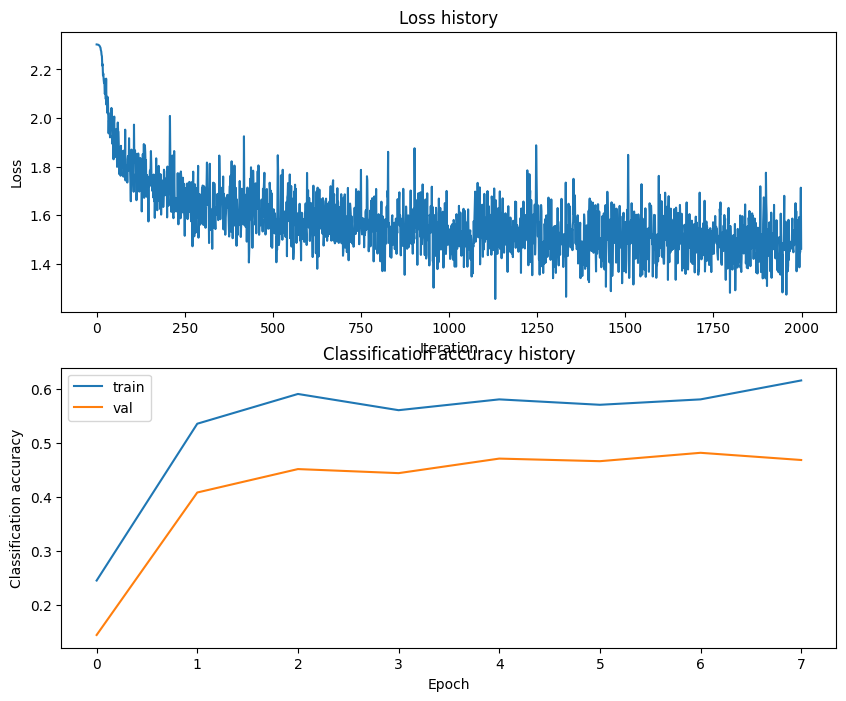

In [17]:
plt.subplot(2, 1, 1)
plt.plot(stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(stats['train_acc_history'], label='train')
plt.plot(stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.show()

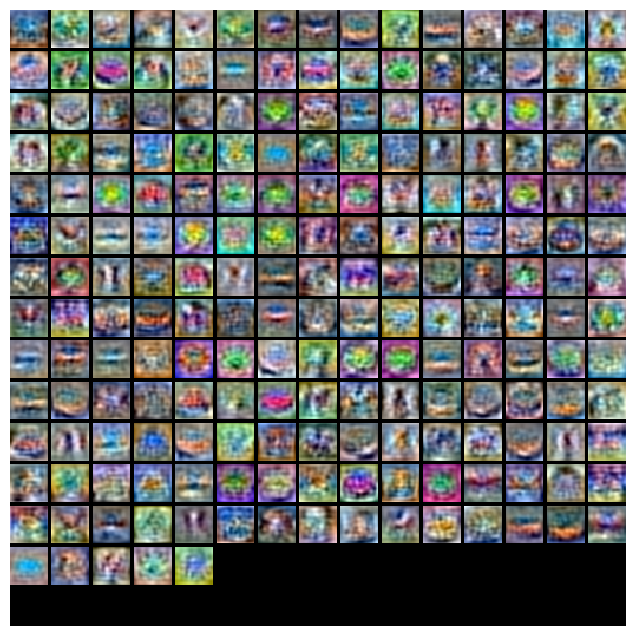

In [ ]:
from scripts.vis_utils import visualize_grid

def show_net_weights_pca(net, pca_transformer):
    W1 = net.params['W1']
    W1_back = pca_transformer.inverse_transform(W1.T)
    W1_back = W1_back.reshape(-1, 32, 32, 3) 

    plt.imshow(visualize_grid(W1_back, padding=3).astype('uint8'))
    plt.gca().axis('off')
    plt.show()

show_net_weights_pca(best_net, pca)

Сделайте выводы по результатам работы. 

#### За время выполнения этой лабораторной работы я рассмотрел принцип построения нейронной сети.
#### Также я смог обучить ее, увидеть результат переобучения - Validation accuracy:  0.2764 и попробовать улучшить его.
#### Сначала я пробовал поиграть с гиперпараметрами - подбирать разные шаги обучения, увеличивать регуляризацию для неправильных ответов, в связи с чем получил максимум ~50 % за 6 с половиной минут.
#### Далее я попробовал сократить количество весов с помощью метода выделения главных компонент (PCA). В результате, убавив веса, обрабатывавших шум, мне удалось получить значение точности в ~51 % за 1,5 минуты.
#### Как итог я уперся в потолок для нейройнной сети, состоящей из 2х полносвязных слоев и теперь нужно либо повышать число слоев, либо экспериментировать с нейронными сетями - например строить уже модели CNN.